# New Architectures Validation — 2026-07-08

Validates the 5 architectures added this session and documents 3 harness bugs found
(and fixed) while validating them, all against task `adi-top-modules` with the local
`qwen3.6-35b-a3b` model. Raw reports live in `reports/20260708_new-architectures/`.

**New architectures:**
- `enterprise-react-toolsearch` / `enterprise-codemode-toolsearch` — tools hidden behind
  `ToolSearch` on-demand discovery instead of sent up front every turn.
- `enterprise-mcp-react-native` — native MCP tool calls made server-side by the model
  provider instead of proxied locally (requires `ENTERPRISE_MCP_PUBLIC_URL`).
- `enterprise-react-thinking` / `enterprise-codemode-thinking` — extended thinking enabled
  before tool calls.

**Bugs found while validating (see section 4):**
1. Segfault-on-exit after every benchmark run (root cause: a fresh `Langfuse()` client
   built per run, each registering a competing `atexit` shutdown hook).
2. Tool-call retry budget defaulted to 1 attempt, too tight for CodeMode + a local model.
3. `SQLError` wasn't a retryable exception type, so one bad query ended the whole run.

This notebook loads three snapshots of the same `run-all` sweep, taken before and after
each fix, to show the fix progression directly rather than just asserting it worked.

In [ ]:
import json
import pathlib

import pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path(__file__).parent.parent if "__file__" in dir() else pathlib.Path.cwd().parent
REPORTS_DIR = ROOT / "reports" / "20260708_new-architectures"

# Three snapshots of the same `agent-bench run-all --task adi-top-modules` sweep,
# taken before and after each fix landed.
STAGES = [
    ("1_before_fixes", "run-all_scored.json"),
    ("2_after_segfault_fix", "run-all-postfix_scored.json"),
    ("3_after_all_fixes", "run-all-final_scored.json"),
]

NEW_ARCHITECTURES = [
    "enterprise-react-toolsearch",
    "enterprise-codemode-toolsearch",
    "enterprise-mcp-react-native",
    "enterprise-react-thinking",
    "enterprise-codemode-thinking",
]

rows = []
for stage, filename in STAGES:
    with open(REPORTS_DIR / filename) as fh:
        payload = json.load(fh)
    for r in payload["results"]:
        rows.append({
            "stage": stage,
            "architecture": r["architecture"],
            "ok": r["ok"],
            "score": (r.get("scores") or {}).get("overall_score", 0.0),
            "elapsed_seconds": r["elapsed_seconds"],
            "error": (r.get("error") or "").replace("\n", " "),
            "is_new": r["architecture"] in NEW_ARCHITECTURES,
        })

df = pd.DataFrame(rows)
df["score"] = df["score"].fillna(0.0)
plt.rcParams["figure.facecolor"] = "white"
pd.set_option("display.max_colwidth", 80)

print(f"{len(df)} rows loaded from {REPORTS_DIR}")
df.head()

36 rows loaded from /Users/srs/Projects/aily/agent_harness/reports/20260708_new-architectures


,stage,architecture,ok,score,elapsed_seconds,error,is_new
0,1_before_fixes,minimal,True,0.0,26.264363,,False
1,1_before_fixes,enterprise-react,True,1.0,4.000755,,False
2,1_before_fixes,enterprise-codemode,False,0.0,3.141301,UnexpectedModelBehavior: Tool 'get_top_selling_products' exceeded max retrie...,False
3,1_before_fixes,enterprise-mcp-react,True,1.0,6.409806,,False
4,1_before_fixes,enterprise-mcp-codemode,False,0.0,4.243196,UnexpectedModelBehavior: Tool 'tool_get_top_selling_products' exceeded max r...,False


---
## 1 · Fix progression: OK rate across the 3 stages

Every stage ran the exact same `run-all` sweep (12 architectures × task
`adi-top-modules`). Stage 1 also segfaulted on process exit (exit code 139) even
though results were already printed and saved correctly — that's a separate axis
from correctness and isn't visible in the scores below, only in the process exit
code (see section 4).

Note stage 2 (`after_segfault_fix`) has the *same* 5 failures as stage 1: the
segfault fix and the correctness fixes were genuinely independent bugs, not one
fix masking the other.

In [ ]:
pivot_ok = df.pivot(index="architecture", columns="stage", values="ok")
pivot_ok = pivot_ok.reindex(columns=[s for s, _ in STAGES])
pivot_ok = pivot_ok.loc[df.groupby("architecture")["is_new"].first().sort_values().index]

ok_counts = df.groupby("stage")["ok"].sum().reindex([s for s, _ in STAGES])
print("OK count per stage (out of 12):")
print(ok_counts.to_string())
print()

pivot_ok.style.map(lambda v: "background-color: #c6efce" if v else "background-color: #ffc7ce")

OK count per stage (out of 12):
stage
1_before_fixes           7
2_after_segfault_fix     7
3_after_all_fixes       11



stage,1_before_fixes,2_after_segfault_fix,3_after_all_fixes
architecture,,,
enterprise-codemode,False,False,True
enterprise-mcp-codemode,False,False,True
enterprise-mcp-react,True,True,True
enterprise-react,True,True,True
enterprise-sql-codemode,True,True,True
enterprise-sql-react,True,True,True
minimal,True,True,True
enterprise-codemode-thinking,False,False,True
enterprise-codemode-toolsearch,False,False,True


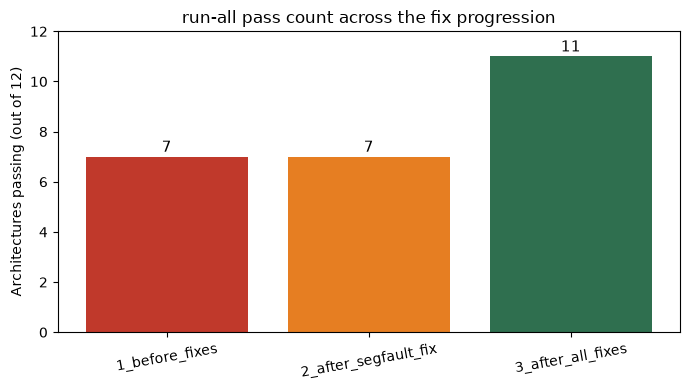

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
stage_labels = [s for s, _ in STAGES]
bars = ax.bar(stage_labels, ok_counts.values, color=["#c0392b", "#e67e22", "#2f6f4f"])
ax.set_ylim(0, 12)
ax.set_ylabel("Architectures passing (out of 12)")
ax.set_title("run-all pass count across the fix progression")
for bar, v in zip(bars, ok_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.2, str(v), ha="center", fontsize=11)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

---
## 2 · Final state: per-architecture scores (stage 3, all fixes applied)

11/12 pass. The one remaining failure, `enterprise-mcp-react-native`, is failing
*by design* — it requires `ENTERPRISE_MCP_PUBLIC_URL` (a public tunnel to the local
MCP server), which isn't configured in this environment. See its README section for
setup instructions.

In [ ]:
final = df[df["stage"] == "3_after_all_fixes"].copy()
final = final.sort_values("is_new").drop(columns=["stage"]).reset_index(drop=True)
final["elapsed_seconds"] = final["elapsed_seconds"].round(1)
final[["architecture", "is_new", "ok", "score", "elapsed_seconds", "error"]]

,architecture,is_new,ok,score,elapsed_seconds,error
0,minimal,False,True,0.0,26.1,
1,enterprise-react,False,True,1.0,5.0,
2,enterprise-codemode,False,True,1.0,8.7,
3,enterprise-mcp-react,False,True,1.0,6.6,
4,enterprise-mcp-codemode,False,True,1.0,7.4,
5,enterprise-sql-react,False,True,0.6,15.8,
6,enterprise-sql-codemode,False,True,1.0,37.9,
7,enterprise-react-toolsearch,True,True,1.0,7.8,
8,enterprise-codemode-toolsearch,True,True,0.0,45.9,
9,enterprise-mcp-react-native,True,False,0.0,0.0,RuntimeError: enterprise-mcp-react-native requires ENTERPRISE_MCP_PUBLIC_URL...


---
## 3 · New architectures vs. their baseline counterpart

Each new architecture is a variant of an existing one (`enterprise-react` or
`enterprise-codemode`) with one capability layered on top. Comparing elapsed time
side by side shows the overhead each capability adds on a single-tool-call task —
this task is too simple to show a *correctness* difference (everything here scores
either 1.0 or crashes), but it's a fair proxy for round-trip/latency overhead.

`enterprise-codemode-toolsearch` scores 0.0 despite `ok=True`: it completed without
crashing (the fix worked) but the model's *content* was wrong — its answer contains
duplicate rows for 2 of the 5 modules (a flawed join after recovering from the first,
retried query). That's a model-quality issue with this combination + the local 35B
model, not a harness bug; worth re-running with a stronger model before drawing
conclusions about `ToolSearch` + `CodeMode` as a pairing.

/var/folders/hn/15rc2jcj40ddy3hc2m3rp6980000gn/T/ipykernel_98729/386388805.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(archs, rotation=25, ha="right")
/var/folders/hn/15rc2jcj40ddy3hc2m3rp6980000gn/T/ipykernel_98729/386388805.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(archs, rotation=25, ha="right")


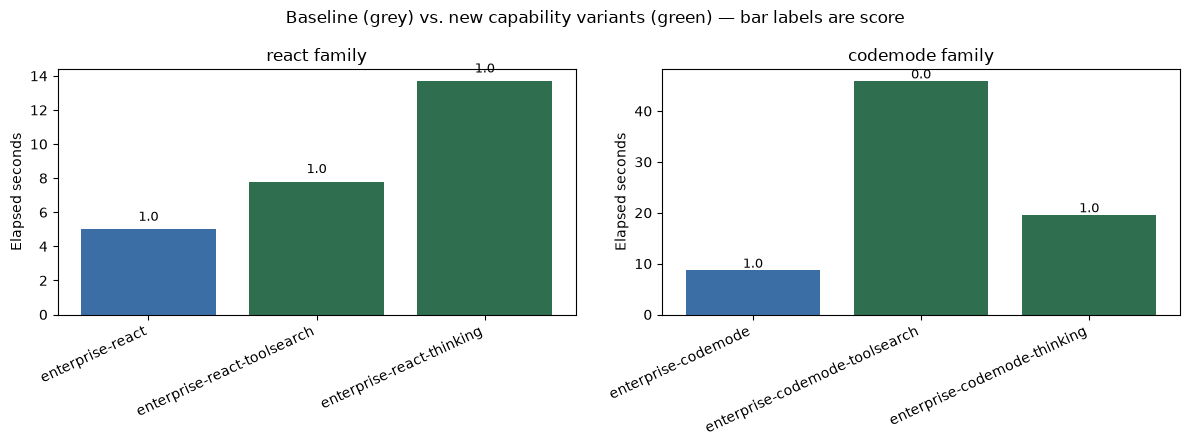

In [ ]:
groups = {
    "react family": ["enterprise-react", "enterprise-react-toolsearch", "enterprise-react-thinking"],
    "codemode family": ["enterprise-codemode", "enterprise-codemode-toolsearch", "enterprise-codemode-thinking"],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
colors = {"enterprise-react": "#7f8c8d", "enterprise-codemode": "#7f8c8d"}

for ax, (title, archs) in zip(axes, groups.items()):
    sub = final[final["architecture"].isin(archs)].set_index("architecture").reindex(archs)
    bar_colors = ["#3b6ea5" if a in colors else "#2f6f4f" for a in archs]
    bars = ax.bar(archs, sub["elapsed_seconds"], color=bar_colors)
    for bar, ok, score in zip(bars, sub["ok"], sub["score"]):
        label = f"{score:.1f}" if ok else "FAIL"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, label, ha="center", fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("Elapsed seconds")
    ax.set_xticklabels(archs, rotation=25, ha="right")

plt.suptitle("Baseline (grey) vs. new capability variants (green) — bar labels are score")
plt.tight_layout()
plt.show()

---
## 4 · Bugs found & fixed

### 4.1 Segfault on process exit

Every `agent-bench` invocation printed/saved results correctly, then crashed with
`Fatal Python error: Segmentation fault` during interpreter shutdown (`Garbage-collecting`,
no Python frame) — exit code 139. Root cause: each architecture run built its own
`Langfuse(...)` client, and every client instance registers its own `atexit` shutdown
hook against *shared* OpenTelemetry SDK state. A `run-all` sweep across 12
architectures registered 12 competing shutdown hooks racing to tear down that shared
state at interpreter exit.

Fix, two parts:
- Memoize the Langfuse client construction to a process-wide singleton with
  `@lru_cache(maxsize=1)`, so only one `atexit` hook is ever registered
  (`traced_agent.py`, `_build_langfuse_client`).
- Belt-and-suspenders: the CLI's `main()` now catches `SystemExit`, explicitly calls
  `shutdown_tracing()` to flush/close that singleton, flushes stdout/stderr, then calls
  `os._exit()` — a hard exit that skips Python's normal GC-based finalization sequence
  entirely (`cli.py`).

### 4.2 Tool-call retry budget too tight for CodeMode + a local model

Every `Agent(...)` defaulted to pydantic-ai's `retries=1`. CodeMode architectures ask
the local `qwen3.6-35b-a3b` model to write a small Python program in one shot; on any
malformed call the single retry was often already consumed by the time the model
self-corrected, and pydantic-ai raised `UnexpectedModelBehavior: Tool '...' exceeded
max retries count of 1`, ending the whole run. Fix: raised the shared retry budget to
`_TOOL_RETRIES = 3` and threaded it through every `Agent(...)` in `runners.py`.

### 4.3 `SQLError` wasn't retryable

Separately, `enterprise-sql-*`/`enterprise-mcp-*` tools raise a plain `sql.py`
`SQLError` on bad SQL (syntax errors, unknown tables) so `sql.py` stays usable
standalone (MCP tools, notebook cells, scripts) without a pydantic-ai dependency. But
pydantic-ai's retry machinery only treats `ValidationError`/`ModelRetry` as
retryable — any other exception propagates straight up and ends the run immediately,
*regardless* of the `retries=` budget above. So a model writing one bad query (e.g.
`SQLError: near "'90'": syntax error`) killed the run even with 3 retries available.

Fix: added a `_retryable()` wrapper in `runners.py` that converts any exception a tool
raises into a `ModelRetry`, applied to `describe_table`/`execute_sql` at the harness
registration layer (`runners.py:102-155`) — without coupling `sql.py` itself to
pydantic-ai.

### Net effect

Stages 1→2 (segfault fix only) leave the same 5/12 failures — confirming the segfault
was an orthogonal exit-path bug, not masking or causing the correctness failures.
Stages 2→3 (retry budget + `_retryable`) take the sweep from 7/12 → 11/12, fixing
`enterprise-codemode`, `enterprise-mcp-codemode`, `enterprise-codemode-toolsearch`, and
`enterprise-codemode-thinking`.

---
## 5 · Known follow-ups

- **`enterprise-mcp-react-native`** needs `ENTERPRISE_MCP_PUBLIC_URL` pointed at a
  publicly reachable tunnel (e.g. `ngrok http 8000`) in front of
  `agent_harness.mcp_server --http`, since native MCP calls are made server-side by the
  model provider and can't reach `localhost`. Not yet exercised end-to-end in this
  environment — only its guard-rail `RuntimeError` has been validated.
- **`enterprise-codemode-toolsearch`** is `ok=True` but scores `0.0` on this run — a
  content-quality issue (duplicate rows from a flawed join), not a crash. Worth
  re-running with a stronger model, and on more than one task, before drawing
  conclusions about the `ToolSearch` + `CodeMode` combination generally.
- This whole notebook is a single-task (`adi-top-modules`), single-run smoke test.
  A full matrix run across all 10 `adi-*` tasks (like
  `../notebooks/benchmark_analysis.ipynb`'s `20260707_full-matrix` sweep) is the
  natural next step to get statistically meaningful scores for the 5 new
  architectures rather than single pass/fail data points.
- Multi-agent router architecture is still deferred to a future session (not
  attempted here).